In [61]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [62]:
Rx_riferimento = 1.9515 * 1000
Rx_riferimento_err = 0.0009139826042 * 1000

data = {

    "R_A" : np.array([
            27.14,
            46.92,
            99.93,
            219.67,
            329.51,
            389.52,
            469.39,
            558.31,
            680.05,
            747.08,
            1001.9,
            1205.9,
            1496.8,
            1797.3,
            2202.7,
    ]),

    "sR_A" : np.array([
        0.04877355704,
        0.05354588811,
        0.07390535592,
        0.1349751939,
        0.1957692861,
        0.2295835581,
        0.2749102715,
        0.3256327462,
        0.3953344586,
        0.4337927794,
        0.0006142376763,
        0.0006714550014,
        0.0007610959242,
        0.0008607827392,
        0.001002899924,
    ]),


    "R_B" : np.array([
            27.17,
            46.97,
            99.8,
            220.21,
            329.66,
            389.51,
            470.38,
            560.44,
            680.25,
            746.67,
            1004.3,
            1212.4,
            1497.8,
            1799.4,
            2200.9,
    ]),

    "sR_B" : np.array([
        0.04877912429,
        0.05356049819,
        0.07384677831,
        0.1352681831,
        0.1958534449,
        0.2295779026,
        0.2754737401,
        0.3268501153,
        0.3954491381,
        0.4335574122,
        0.0006148775109,
        0.000673364127,
        0.0007614171812,
        0.0008614990378,
        0.001002254259,
    ]),

    "k" : np.array([
        1.666666667,
        1.352569883,
        1.142857143,
        1.072961373,
        1.088139282,
        1.102941176,
        1.121914734,
        1.148545176,
        1.19379228,
        1.218026797,
        1.307189542,
        1.378676471,
        1.49551346,
        1.610305958,
        1.769911504,
    ]),

    "sk" : np.array([
        0.05064926371,
        0.0410539499,
        0.03466526908,
        0.03253868943,
        0.03300037178,
        0.03345066952,
        0.03402796134,
        0.03483838342,
        0.03621579007,
        0.03695376941,
        0.03967037977,
        0.04185018909,
        0.04541641649,
        0.04892488779,
        0.05381131626,
    ]),

    "rho" : np.array([
        0.998895841,
        0.9989354907,
        1.001302605,
        0.9975477953,
        0.9995449857,
        1.000025673,
        0.9978953187,
        0.9961994147,
        0.9997059904,
        1.000549105,
        0.9976102758,
        0.9946387331,
        0.9993323541,
        0.9988329443,
        1.000817847
    ]),

    "sigma_rho" : np.array([
        0.002537434164,
        0.001611567849,
        0.001047540664,
        0.0008667016728,
        0.0008398230726,
        0.0008335610131,
        0.0008265026096,
        0.0008216698895,
        0.0008218834713,
        0.00082161804,
        0.0008643601194,
        0.0007822325737,
        0.000718533774,
        0.000676406693,
        0.0006444807734,
    ])
}

### Slide 1

In [63]:
A = False
# Se A==True usiamo R_A, altrimenti R_B.
# Questo ci permette di fare la regressione su entrambi i set di dati senza dover riscrivere tutto il codice.

<>:80: SyntaxWarning: invalid escape sequence '\c'
<>:80: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3546/2588189872.py:80: SyntaxWarning: invalid escape sequence '\c'
  gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")


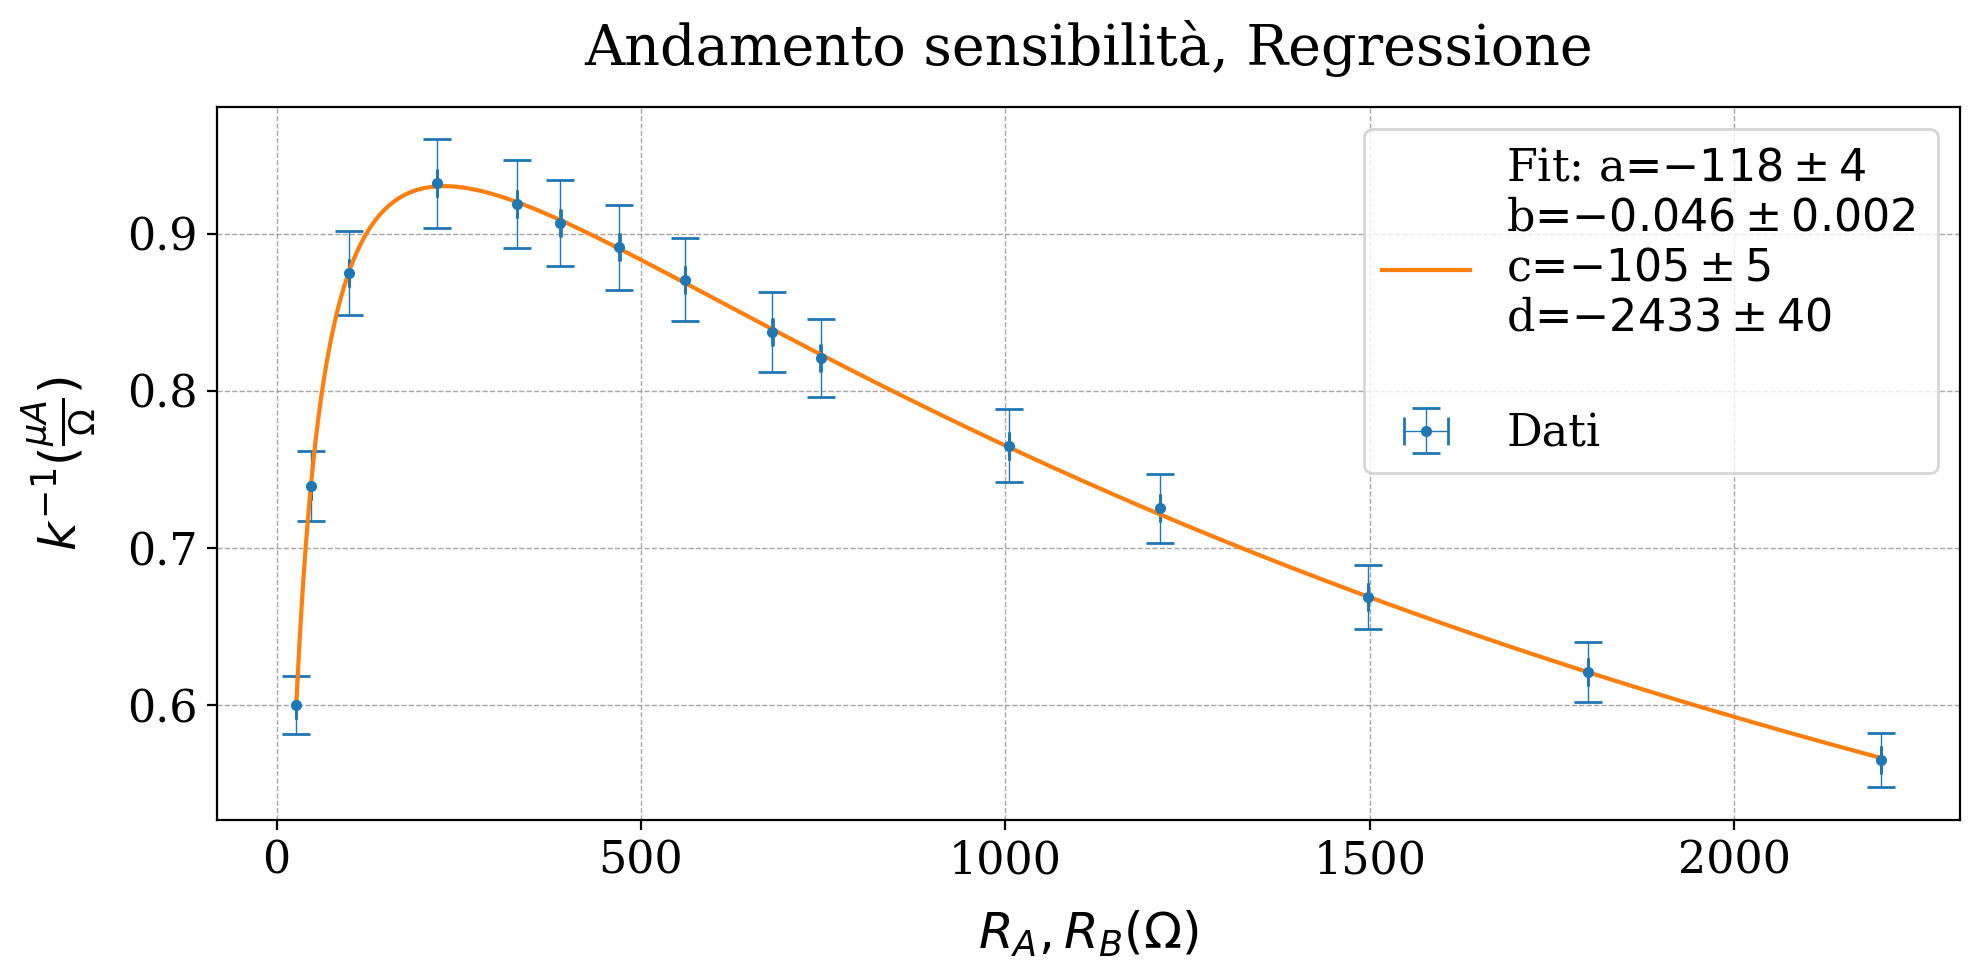

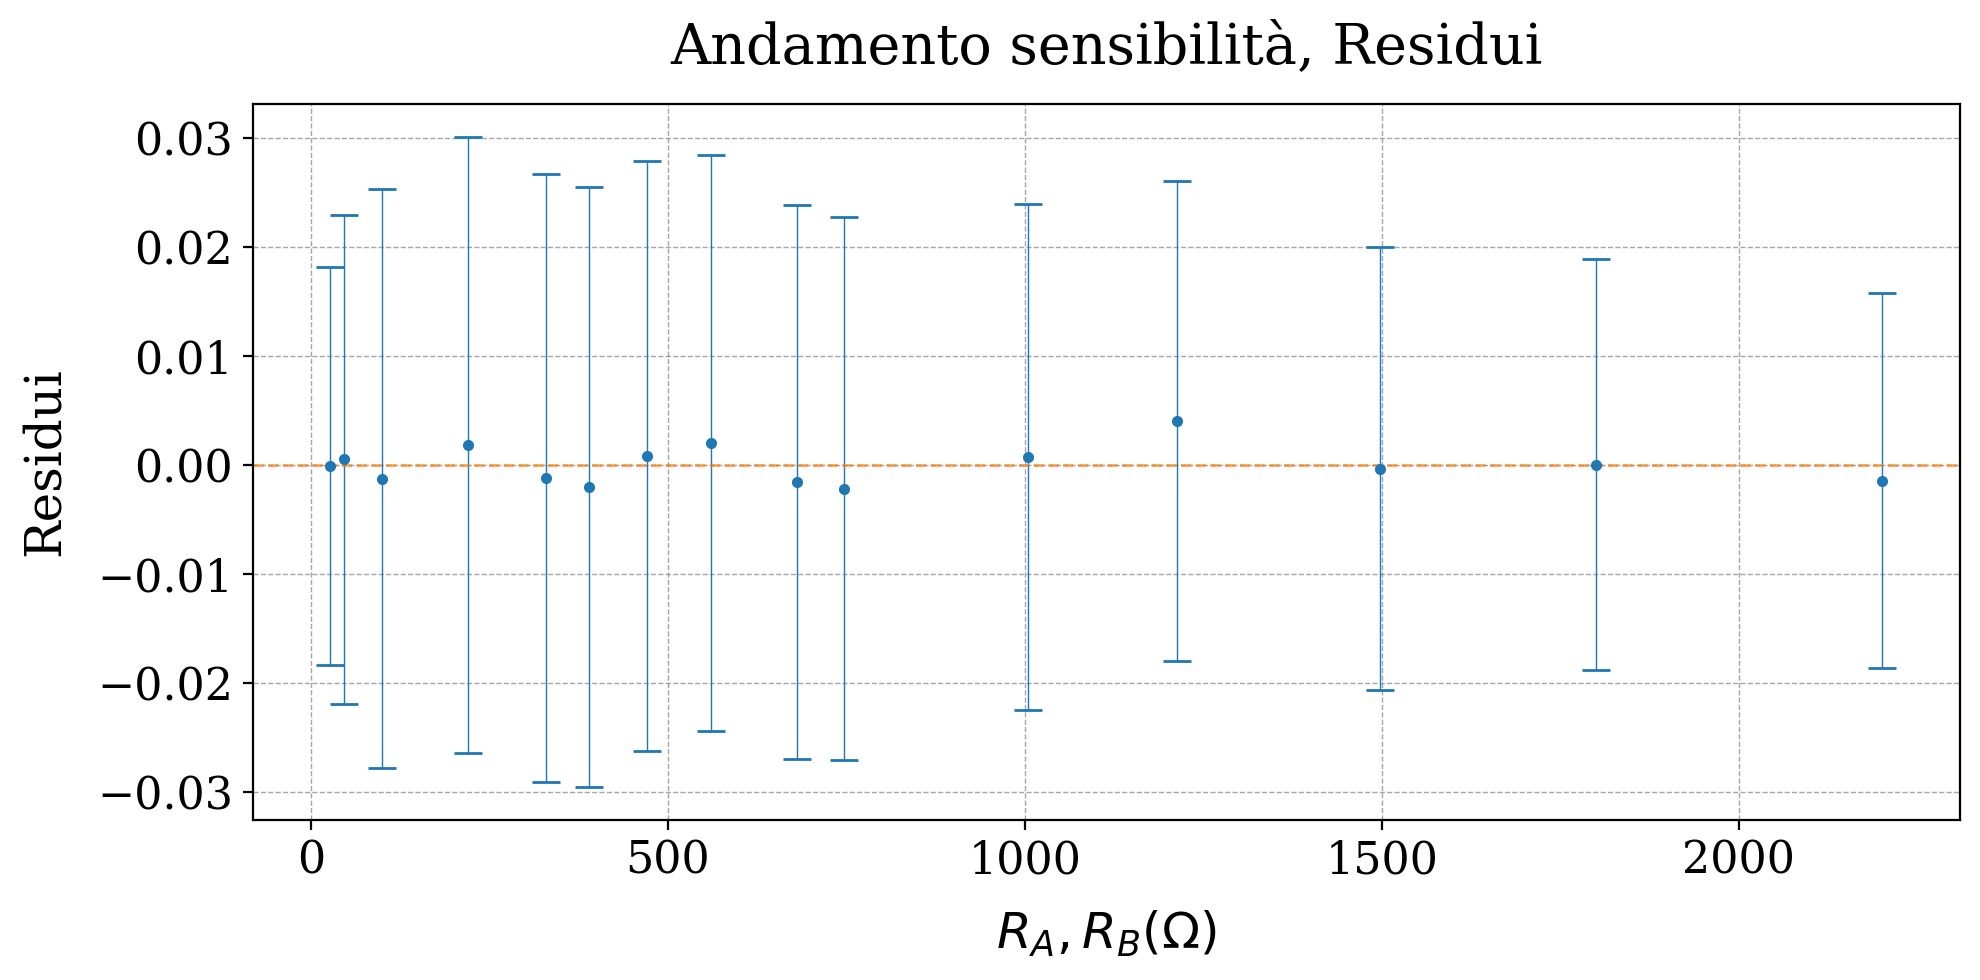

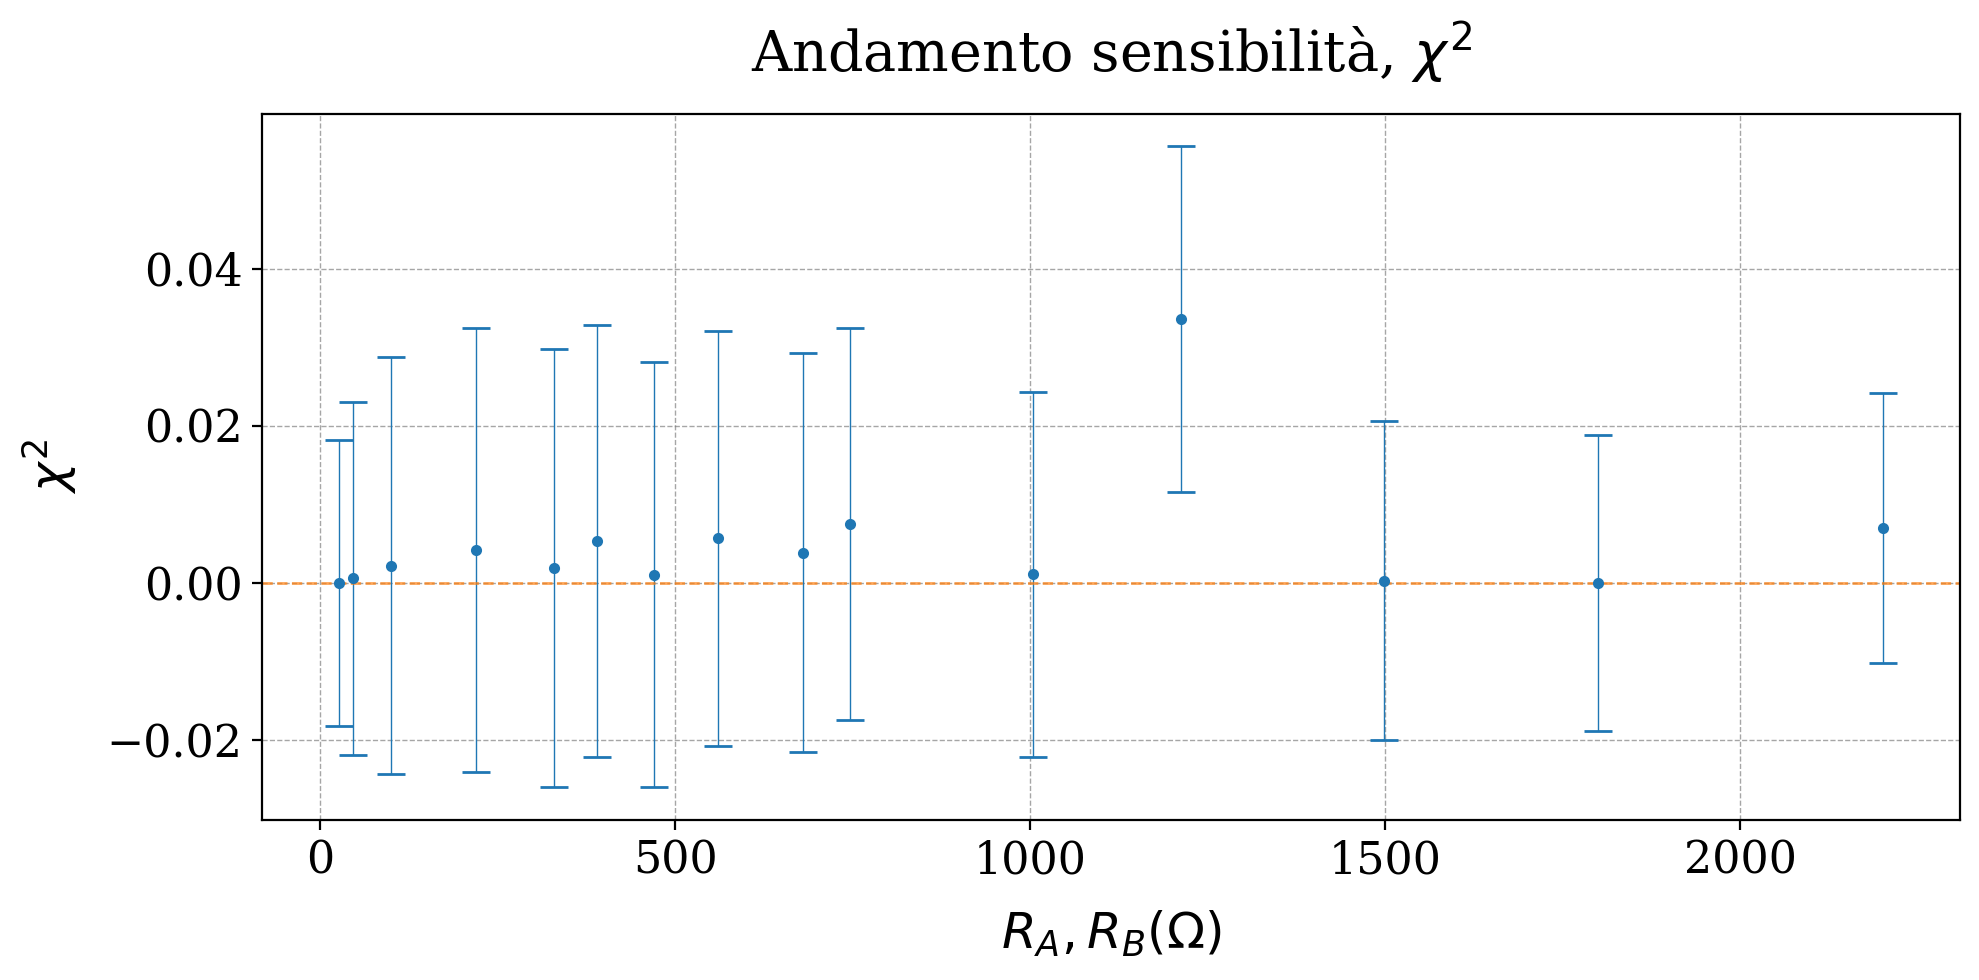

In [67]:
titolo = "Andamento sensibilità"
xlabel = r"$R_A,R_B (Ω)$"
ylabel = r"$k^{-1} (\frac{μA}{Ω})$"
file_output1 = "residui.txt"
file_output2 = "chi.txt"
grafico_output1 = "Slide 1.pdf"
grafico_output2 = "Slide 1, Residui.pdf"
grafico_output3 = "Slide 1, Chi.pdf"

#####################################
## Regressione
#####################################
if A==True:
    quali_dati = "R_A"
else:
    quali_dati = "R_B"

xdata = np.array([data[quali_dati], data["s" + quali_dati]])
ydata = np.array([1/data["k"], data["sk"]/(data["k"]**2)])
def modello(par, x):
    return (par[0] * x) / (par[1] * x**2 + par[2] * x + par[3])
anal = f.fit(xdata,ydata,modello,[-0.1,-10.,-1.,-0.1])

#####################################
### Grafico Regressione
#####################################

fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Regressione",xlabel=xlabel,ylabel=ylabel)

# Grafico dei dati con errori
ax.errorbar(xdata[0],ydata[0],xerr=xdata[1],yerr=ydata[1],
            label="Dati", **gf.errorbar_params, color = gf.colori[0])
# Grafico del fit
param_labels = ['a','b','c','d']  # cambia i nomi se vuoi
fit_label = "Fit: " + "".join(
    f"{param_labels[i]}={gf.formatta_errore(anal[i,0],anal[i,1])}\n" for i in range(len(param_labels))
)
x_fit = np.linspace(min(xdata[0]), max(xdata[0]), 500)
ax.plot(x_fit,modello(anal[:,0],x_fit),
        label=fit_label, **gf.plot_params, color = gf.colori[1])

ax.legend()

gf.salva_grafico(fig,grafico_output1)

#####################################
### Residui
#####################################

f.inizializza_output(file_output1)
res = f.residui(xdata,ydata,anal[:,0],modello,file_output1,titolo)

#####################################
### Grafico Residui
#####################################

fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Residui",xlabel=xlabel,ylabel="Residui")

ax.errorbar(res[0],res[1],yerr=res[2],
            **gf.errorbar_params, color=gf.colori[0])
ax.axhline(0,
           **gf.line_params, color=gf.colori[1])

gf.salva_grafico(fig,grafico_output2)

#####################################
### Chi
#####################################

f.inizializza_output(file_output2)
chi = f.chi_quadro(xdata,ydata,anal[:,0],modello,file_output2,titolo)

#####################################
### Grafico Chi
#####################################

fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")

ax.errorbar(chi[0],chi[1],yerr=chi[2],
            **gf.errorbar_params, color=gf.colori[0])
ax.axhline(0,
           **gf.line_params, color=gf.colori[1])

gf.salva_grafico(fig,grafico_output3)

### Slide 2

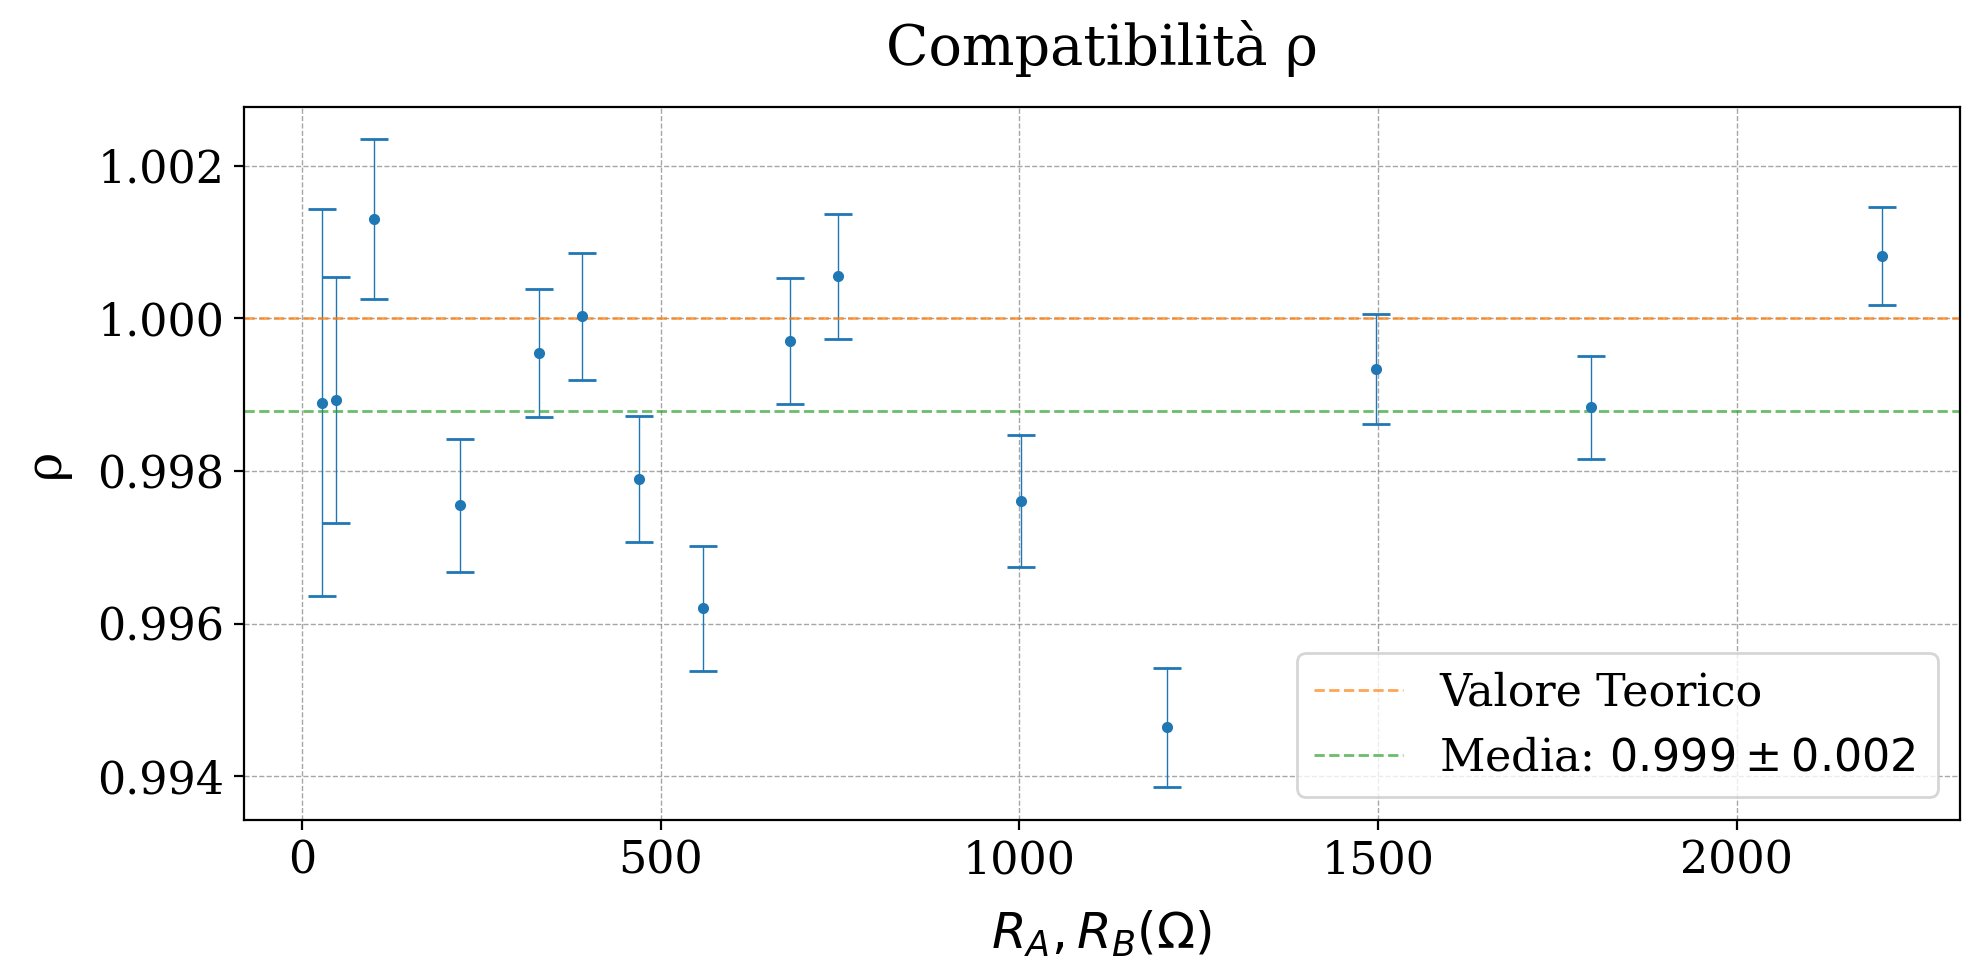

In [68]:
dati = data["rho"]
errori = data["sigma_rho"]

fig,ax = plt.subplots(1, 1,  figsize=(10, 5), sharex=True, sharey=True)
gf.parametri_grafico(ax,"Compatibilità ρ",xlabel=r"$R_A, R_B (Ω)$",ylabel="ρ")
ax.errorbar(data["R_A"],dati,errori, color=gf.colori[0], **gf.errorbar_params)
ax.axhline(y=1, color=gf.colori[1], label="Valore Teorico", **gf.line_params)
errore = 0.001721694905
ax.axhline(y=np.mean(dati), color=gf.colori[2], **gf.line_params, label=f"Media: {gf.formatta_errore(np.mean(dati),errore)}")

plt.legend(loc="lower right", frameon=True)
gf.salva_grafico(fig,"Slide 2.pdf")

### Slide 3

In [69]:
risultati = {
    "Metodo A": {
        "valori": [
            1952.495029,
            1956.878672,
            1952.013541,
            1952.977437,
            1952.486997
        ],
        "casuale": [
            0.62252,
            10.98559261,
            1.021434682,
            0.6627511899,
            0.929403498
        ],
        "totale": [
            0.8945135789,
            11.00435679,
            1.206628444,
            0.9229639929,
            1.129785048
        ]
    },
    "Metodo B": {
        "valori": [
            1953.357057,
            1953.76924,
            1953.456623,
            1953.257877,
            1953.302555
        ],
        "casuale": [
            1.06228,
            1.85249547,
            1.490982329,
            1.249007674,
            0.9249828714
        ],
        "totale": [
            1.24139526,
            1.960704684,
            1.623469032,
            1.404508299,
            1.12615128
        ]
    }
}

In [70]:
# Digitare "True" se si vogliono due grafici separati
separati = True
offset = 0.04

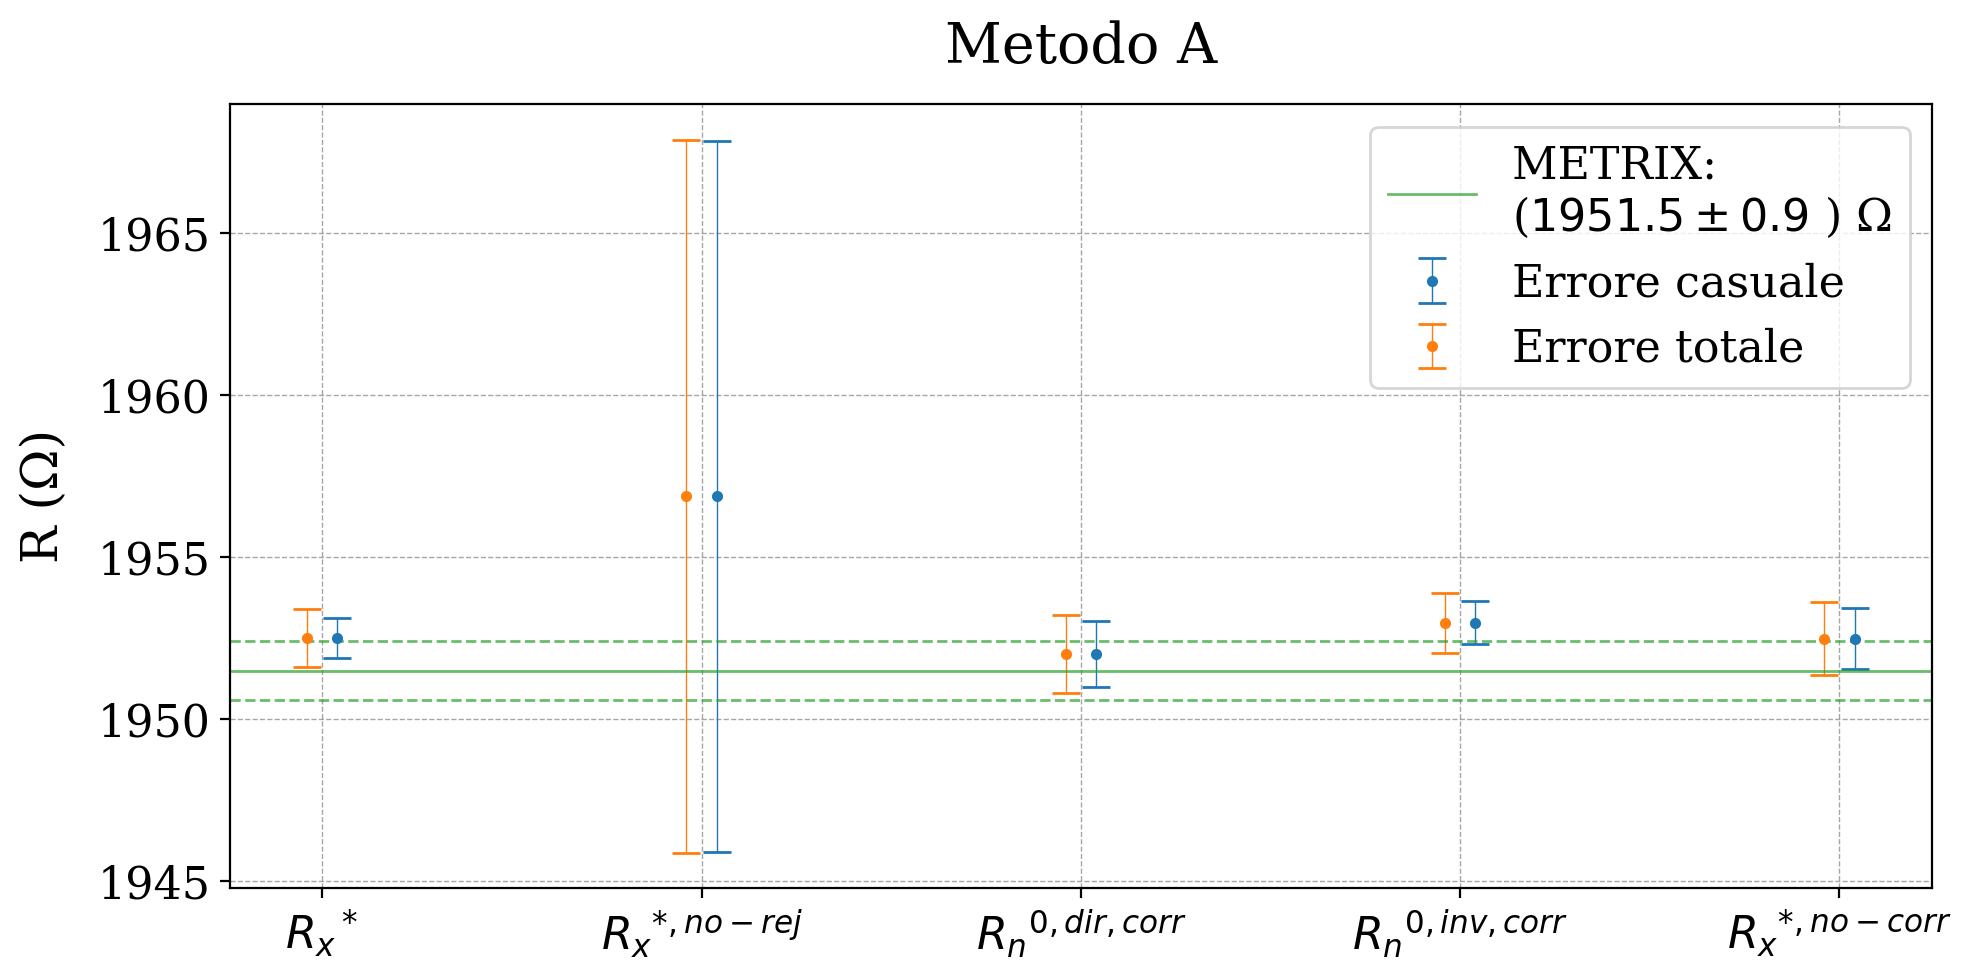

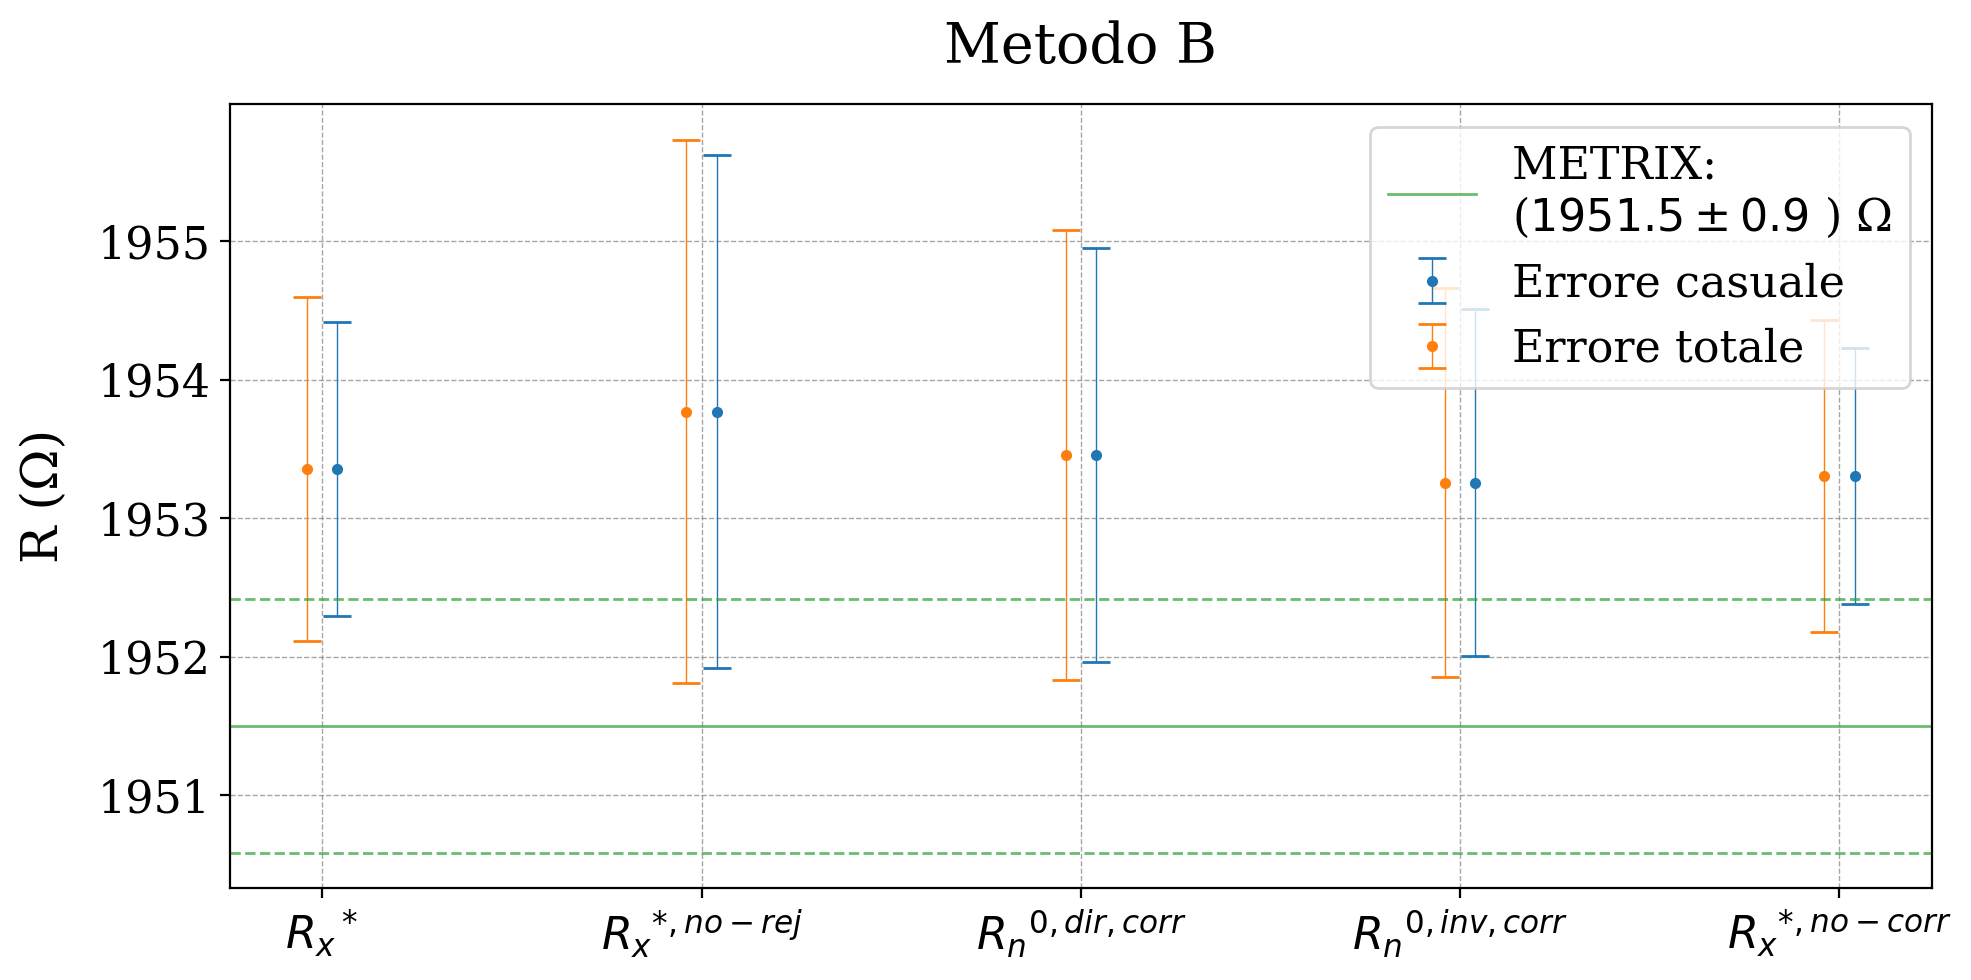

In [71]:
labels = [r"${R_x}^*$", r"${R_x}^{*, no-rej}$", r"${R_n}^{0,dir,corr}$", r"${R_n}^{0,inv,corr}$", r"${R_x}^{*, no-corr}$"]
x = np.array([1,2,3,4,5])

if separati:
    for i, (metodo,dati)  in enumerate(risultati.items()):

        fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
        gf.parametri_grafico(ax,metodo,xlabel="",ylabel="R (Ω)")

        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.errorbar(x + offset, dati["valori"], dati["casuale"], color=gf.colori[0], label="Errore casuale", **gf.errorbar_params)
        ax.errorbar(x - offset, dati["valori"], dati["totale"], label="Errore totale", color=gf.colori[1], **gf.errorbar_params)

        ax.axhline(y=Rx_riferimento, color=gf.colori[2], **gf.line_params_, label=f"METRIX: \n({gf.formatta_errore(Rx_riferimento, Rx_riferimento_err)}) Ω")
        ax.axhline(y=Rx_riferimento + Rx_riferimento_err, color=gf.colori[2], **gf.line_params)
        ax.axhline(y=Rx_riferimento - Rx_riferimento_err, color=gf.colori[2], **gf.line_params)
        ax.legend(loc="upper right", frameon=True)
        gf.salva_grafico(fig,f"Slide 3.{i+1}.pdf")

In [72]:
if not separati:
    fig, ax = plt.subplots(1,1, figsize=(10,5))
    gf.parametri_grafico(ax, "Confronto metodi", xlabel="", ylabel="R (Ω)")

    ax.set_xticks(x)
    ax.set_xticklabels(labels)

    colori = {
        "Metodo A": "blue",
        "Metodo B": "green"
    }

    offset_val = {
        "Metodo A": -2*offset,
        "Metodo B": 2*offset
    }

    metod = ["A","B"]

    for i,(metodo,dati) in enumerate(risultati.items()):

        x_plot = x + offset_val[metodo]

        ax.errorbar(
            x_plot + offset,
            dati["valori"],
            dati["casuale"],
            fmt="o",
            color=colori[metodo],
            label=f"{metod[i]} – err casuale",
            **gf.default_error_params()
        )

        ax.errorbar(
            x_plot - offset,
            dati["valori"],
            dati["totale"],
            fmt="o",
            color=colori[metodo],
            alpha=0.4,
            label=f"{metod[i]} – err totale",
            **gf.default_error_params()
        )

    ax.axhline(y=Rx_riferimento, color="red", label=f"METRIX: \n({gf.formatta_errore(Rx_riferimento, Rx_riferimento_err)}) Ω")
    ax.axhline(y=Rx_riferimento + Rx_riferimento_err, color="red", linestyle="dashed", alpha=0.5)
    ax.axhline(y=Rx_riferimento - Rx_riferimento_err, color="red", linestyle="dashed", alpha=0.5)

    # Legenda fuori
    #ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    # Legenda dentro
    ax.legend(loc="upper right", frameon=True)
    gf.salva_grafico(fig, "Slide 3.pdf")